In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC
0,0,3.90,745,18712,10250,11576,11855,967,611
1,0,0.66,749,11239,6313,4712,18968,1133,447
2,1,7.86,746,4355,5240,3478,14699,894,723
3,1,3.48,750,8502,8416,5890,8748,1127,1024
4,0,1.19,746,17845,18095,12058,11380,1744,276


In [14]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

XGBoost Test Accuracy: 0.9153

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      6278
           1       0.92      0.91      0.91      6322

    accuracy                           0.92     12600
   macro avg       0.92      0.92      0.92     12600
weighted avg       0.92      0.92      0.92     12600

Confusion Matrix:
[[5796  482]
 [ 585 5737]]


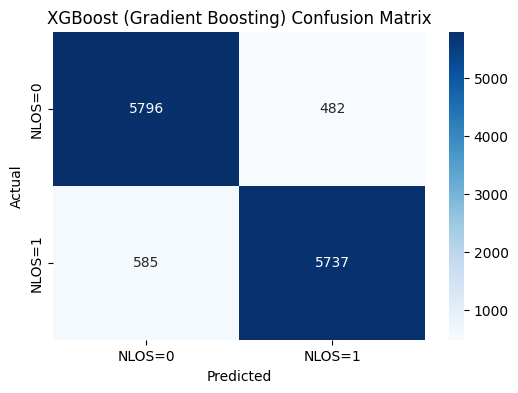

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create and train the XGBClassifier (Gradient Boosting)
xgb_model = XGBClassifier(eval_metric='logloss', random_state=111)
xgb_model.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# 3. Evaluate the performance
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Test Accuracy: {:.4f}".format(accuracy_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:")
print(cm_xgb)

# 4. Visualize the confusion matrix with custom labels
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost (Gradient Boosting) Confusion Matrix")
plt.show()



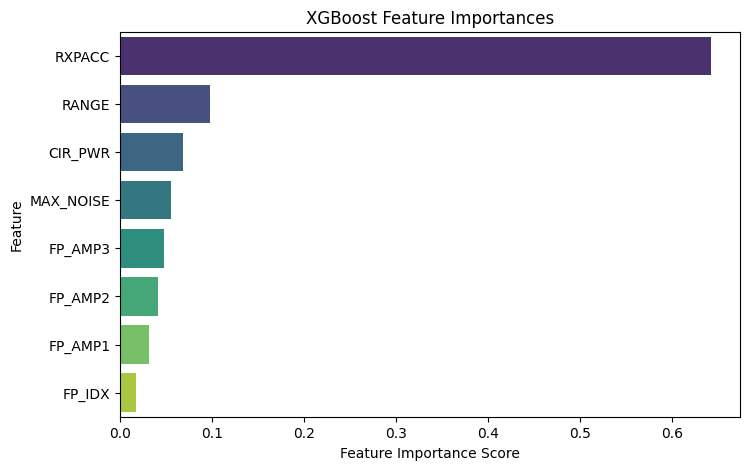

In [17]:
# 5. Extract and visualize feature importances from the XGBoost model
# XGBoost provides feature importances from its internal tree structure.
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=feature_importances.values, 
                 y=feature_importances.index, 
                 hue=feature_importances.index, 
                 palette="viridis", 
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importances")
plt.show()